## Unpickle loss_by_param
This should be a file in the `results` directory and then see what is inside.

In [14]:
# Specify the file name
file_name : str = "Thermal_loss_by_param.pkl"

In [15]:
# Get the full path to the file
import os;
import pickle;
file_path = os.path.abspath(os.path.join(os.path.curdir, 'results', file_name))

# Load the data
with open(file_path, 'rb') as f:
    loss_by_param = pickle.load(f)

In [16]:
# Let's see what's in the file
assert isinstance(loss_by_param, dict), "loss_by_param must be a dictionary";

print("loss_by_param keys and value types");
for key, value in loss_by_param.items():
    print("%20s \t: %s" % (key, type(value)));

loss_by_param keys and value types
               recon 	: <class 'dict'>
                  LD 	: <class 'dict'>
                coef 	: <class 'dict'>
         rollout_ROM 	: <class 'dict'>
         rollout_FOM 	: <class 'dict'>
      IC_rollout_ROM 	: <class 'dict'>
      IC_rollout_FOM 	: <class 'dict'>
               total 	: <class 'dict'>


### Plot Setup

In [50]:
# Check mpl rc params
import matplotlib as mpl;
for key, value in mpl.rcParams.items():
    print("%s" % (key));

_internal.classic_mode
agg.path.chunksize
animation.bitrate
animation.codec
animation.convert_args
animation.convert_path
animation.embed_limit
animation.ffmpeg_args
animation.ffmpeg_path
animation.frame_format
animation.html
animation.writer
axes.autolimit_mode
axes.axisbelow
axes.edgecolor
axes.facecolor
axes.formatter.limits
axes.formatter.min_exponent
axes.formatter.offset_threshold
axes.formatter.use_locale
axes.formatter.use_mathtext
axes.formatter.useoffset
axes.grid
axes.grid.axis
axes.grid.which
axes.labelcolor
axes.labelpad
axes.labelsize
axes.labelweight
axes.linewidth
axes.prop_cycle
axes.spines.bottom
axes.spines.left
axes.spines.right
axes.spines.top
axes.titlecolor
axes.titlelocation
axes.titlepad
axes.titlesize
axes.titleweight
axes.titley
axes.unicode_minus
axes.xmargin
axes.ymargin
axes.zmargin
axes3d.automargin
axes3d.grid
axes3d.xaxis.panecolor
axes3d.yaxis.panecolor
axes3d.zaxis.panecolor
backend
backend_fallback
boxplot.bootstrap
boxplot.boxprops.color
boxplot.box

In [51]:
# Let's setup plot settings so that our plots will look nice.
import matplotlib as mpl;
mpl.rcParams['figure.figsize']  = (10, 6);
mpl.rcParams['figure.dpi']      = 100;
mpl.rcParams['axes.grid']       = True;
mpl.rcParams['axes.grid.which'] = 'both';
mpl.rcParams['grid.linestyle']  = '--';
mpl.rcParams['lines.linewidth'] = 2;
mpl.rcParams['axes.linewidth']  = 1.5;
mpl.rcParams['axes.edgecolor']  = "black";
mpl.rcParams['grid.color']      = "gray";
mpl.rcParams['grid.linestyle']  = "dotted";
mpl.rcParams['grid.linewidth']  = .67;
mpl.rcParams['xtick.labelsize'] = 10;
mpl.rcParams['ytick.labelsize'] = 10;
mpl.rcParams['axes.labelsize']  = 11;
mpl.rcParams['axes.titlesize']  = 11;
mpl.rcParams['xtick.direction'] = 'in';
mpl.rcParams['ytick.direction'] = 'in';
mpl.rcParams['axes.facecolor']  = 'gainsboro';

## Reconstruction loss

In [21]:
# Extract the reconstruction loss from the loss_by_param dictionary.
reconstruction_loss : dict = loss_by_param['recon'];

# Extract the keys. We will use these when plotting.
recon_keys : list[dict] = list(reconstruction_loss.keys());

# Let's see what's in here.
print("reconstruction_loss keys and value types:");
for key, value in reconstruction_loss.items():
    print("%20s \t: %s" % (key, type(value)));

reconstruction_loss keys and value types:
   (1.5e-09, 0.0001) 	: <class 'dict'>
  (1.5e-09, 0.00014) 	: <class 'dict'>
   (3.5e-09, 0.0001) 	: <class 'dict'>
  (3.5e-09, 0.00014) 	: <class 'dict'>
               total 	: <class 'dict'>
  (1.5e-09, 0.00011) 	: <class 'dict'>


In [22]:
# Check what's in the "total" key.
total_loss : dict = reconstruction_loss['total'];

# Let's see what's in here.
print("total_loss keys and value types:");
for key, value in total_loss.items():
    print("%20s \t: %s" % (key, type(value)));


total_loss keys and value types:
              epochs 	: <class 'list'>
              losses 	: <class 'list'>


key: (1.5e-09, 0.0001)


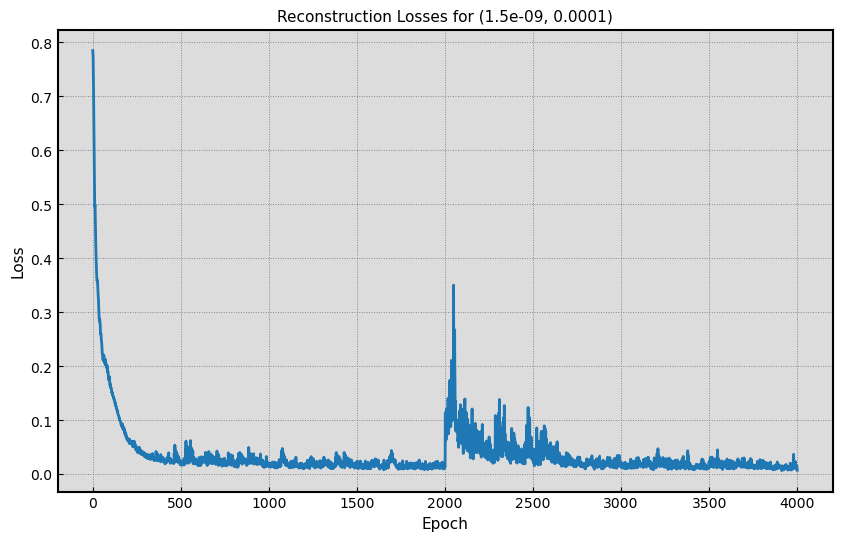

key: (1.5e-09, 0.00014)


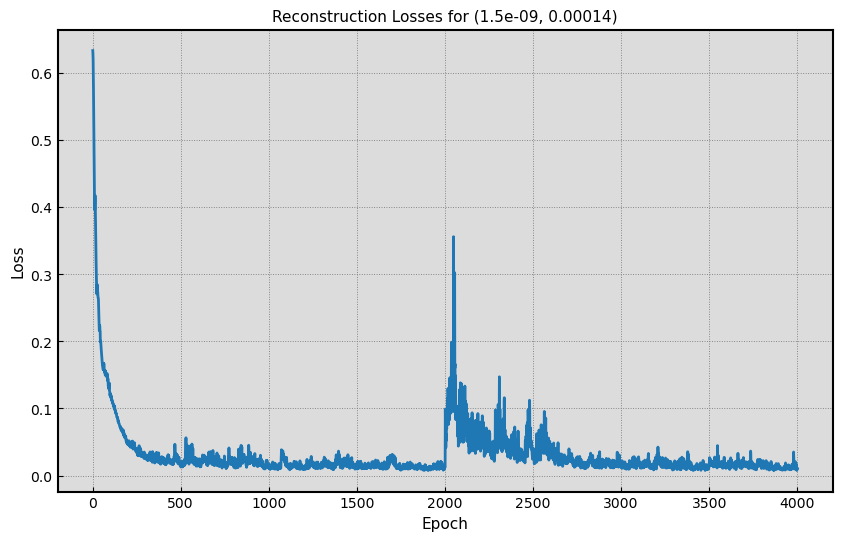

key: (3.5e-09, 0.0001)


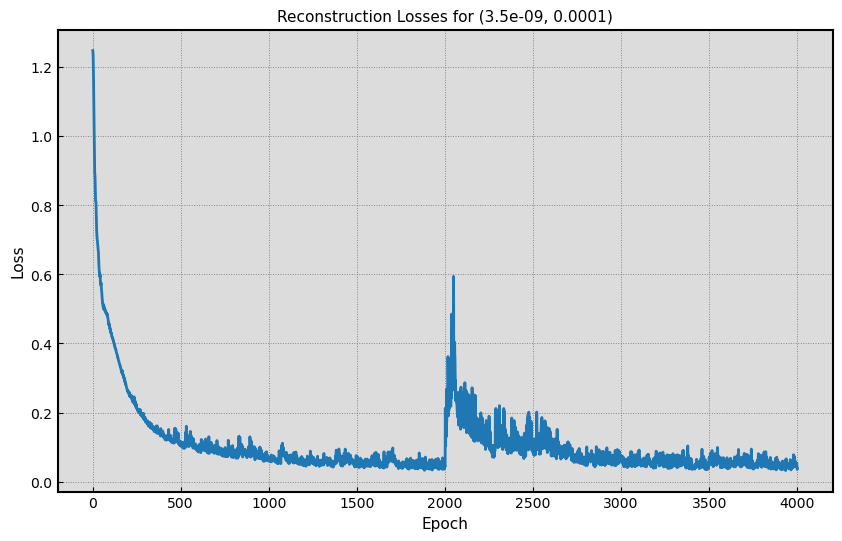

key: (3.5e-09, 0.00014)


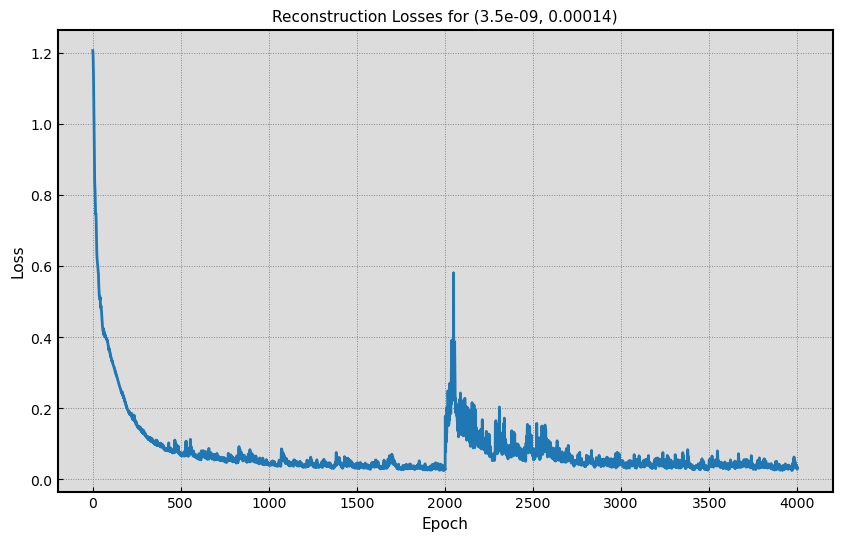

key: total


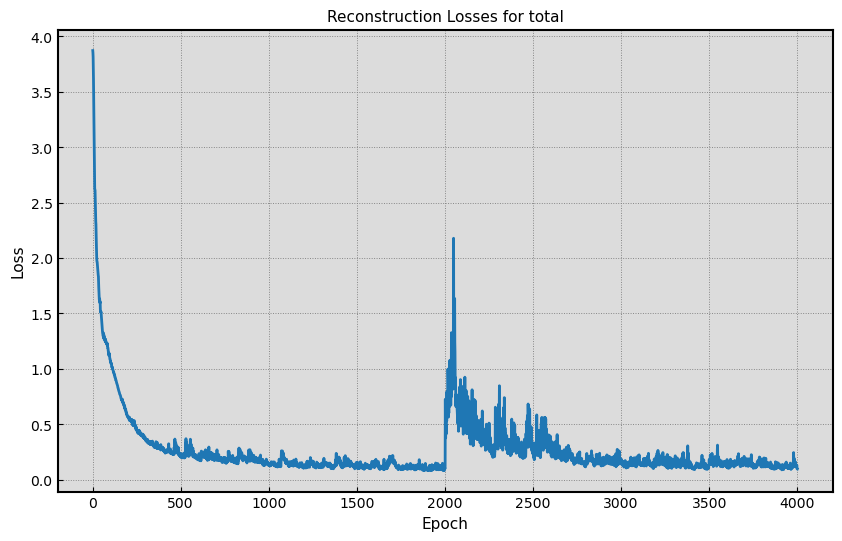

key: (1.5e-09, 0.00011)


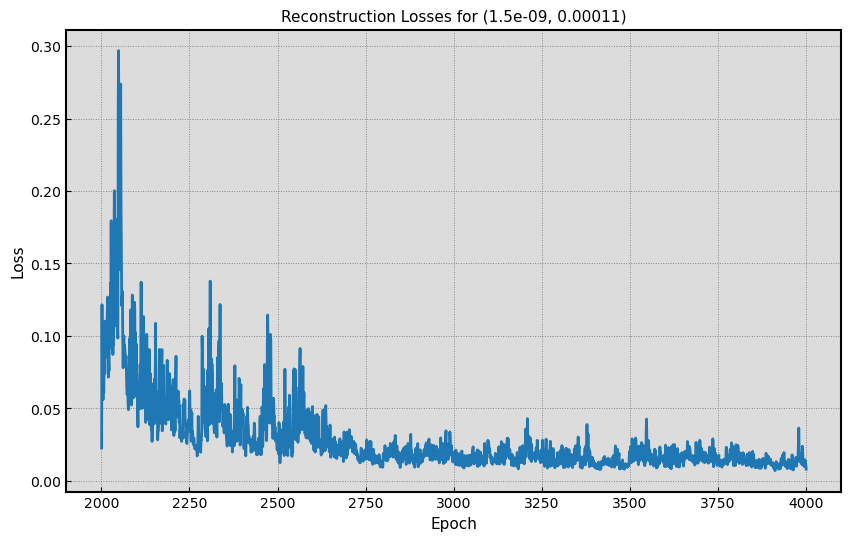

In [49]:
import matplotlib.pyplot as plt;

# Each key should correspond to a parameter combination.
for key in recon_keys:
    print("key: %s" % str(key));
    param_dict : dict = reconstruction_loss[key];

    # Extract the epochs, losses.
    epochs : list[int] = list(param_dict['epochs']);
    losses : list[float] = list(param_dict['losses']);

    # Plot the losses.
    plt.plot(epochs, losses);
    plt.title("Reconstruction Losses for %s" % str(key));
    plt.xlabel("Epoch");
    plt.ylabel("Loss");
    plt.show();

### Loss plotting function 

In [59]:
import matplotlib.pyplot as plt;

def LossPlot(loss_dict : dict, loss_type : str, log_y_scale : bool = False):
    # Extract the keys (each should correspond to a parameter combination)
    params : list[dict] = list(loss_dict.keys());

    # Let's see what's in the loss dictionary.
    print("keys in %s and value types:" % loss_type);
    for key, value in loss_dict.items():
        print("%20s \t: %s" % (key, type(value)));

    # Each key should correspond to a parameter combination.
    for key in params:
        # Extract the parameter dictionary. This should have the epochs and losses.
        param_dict : dict = loss_dict[key];

        # Extract the epochs, losses.
        epochs : list[int] = list(param_dict['epochs']);
        losses : list[float] = list(param_dict['losses']);

        # Plot the losses.
        plt.plot(epochs, losses);
        plt.title("%s Losses for %s" % (loss_type, str(key)));
        plt.xlabel("Epoch");
        plt.ylabel("Loss");
        if(log_y_scale == True):
            plt.yscale('log');
        plt.show();

## Plot Losses

keys in IC Rollout ROM and value types:
   (1.5e-09, 0.0001) 	: <class 'dict'>
  (1.5e-09, 0.00014) 	: <class 'dict'>
   (3.5e-09, 0.0001) 	: <class 'dict'>
  (3.5e-09, 0.00014) 	: <class 'dict'>
               total 	: <class 'dict'>
  (1.5e-09, 0.00011) 	: <class 'dict'>


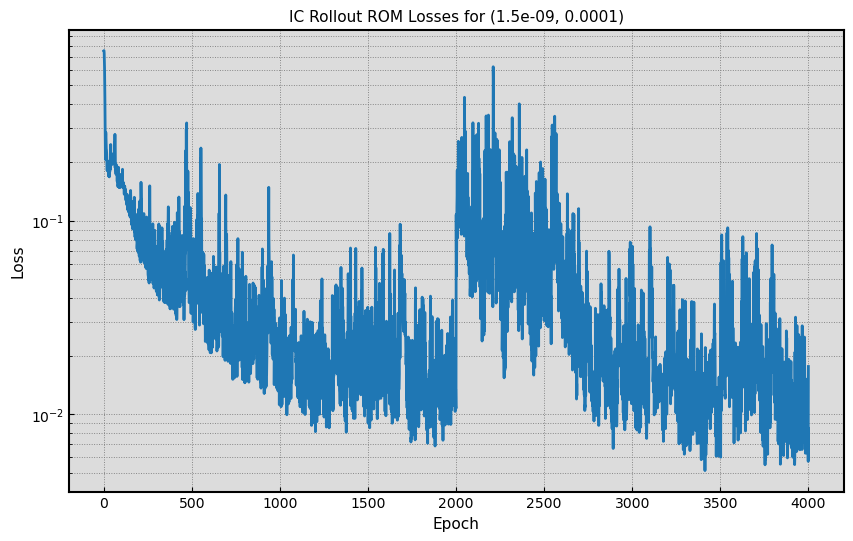

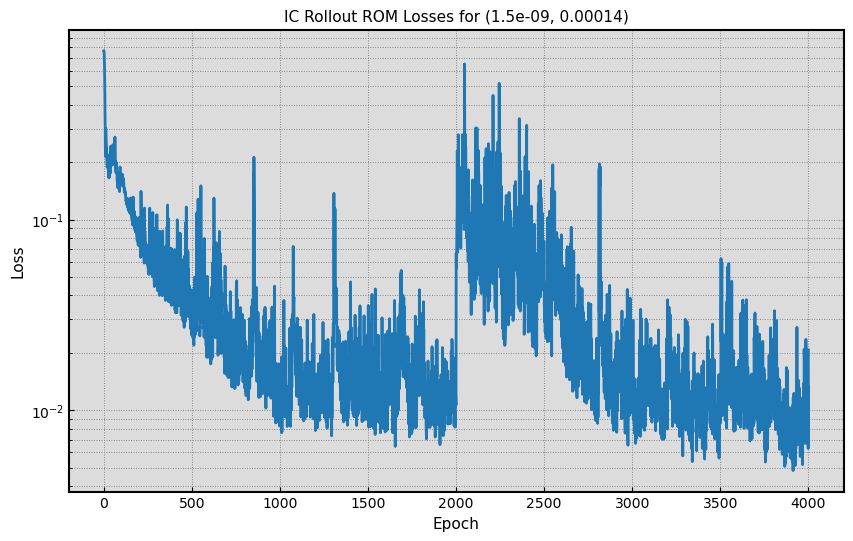

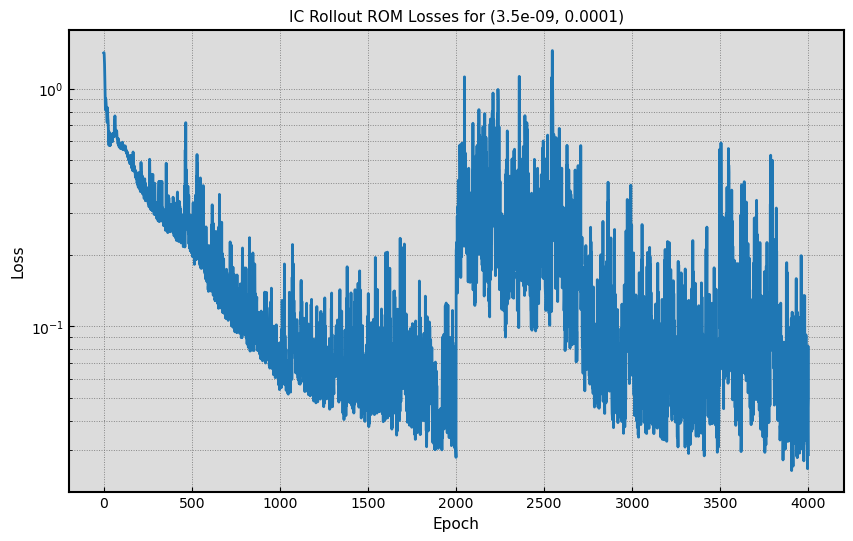

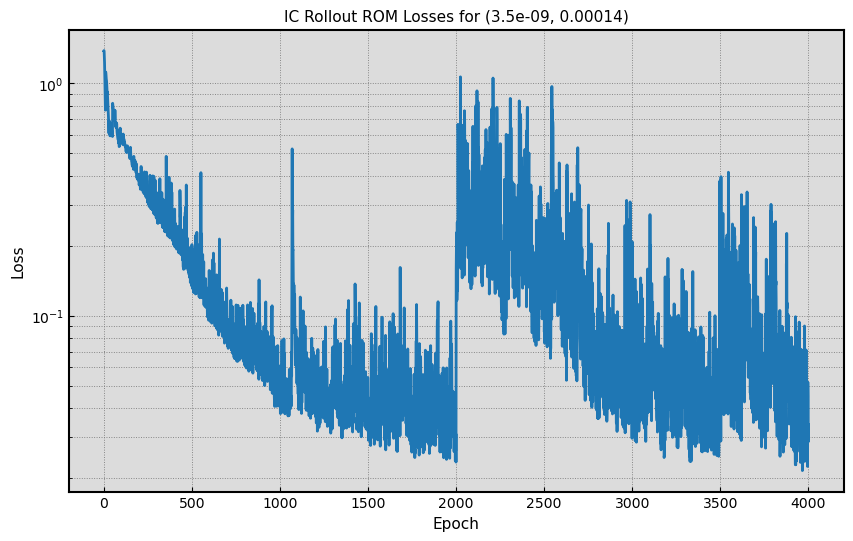

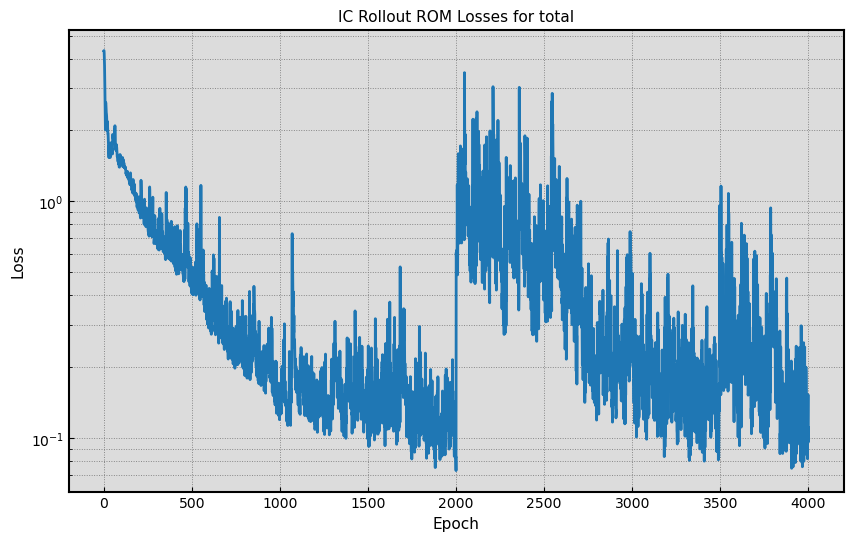

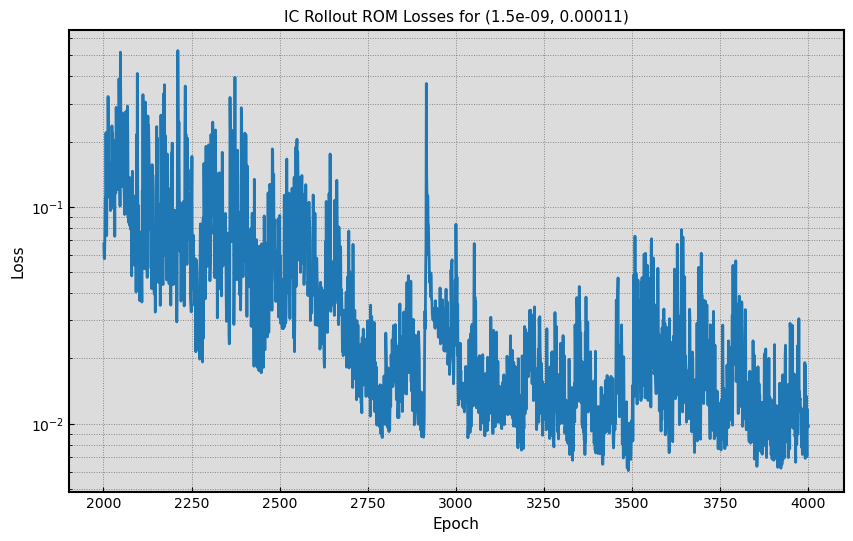

In [63]:
# Call our function for each loss type.
rollout_ROM_losses : dict = loss_by_param['rollout_ROM'];
rollout_FOM_losses : dict = loss_by_param['rollout_FOM'];
rollout_IC_ROM_losses : dict = loss_by_param['IC_rollout_ROM'];
rollout_IC_ROM_losses : dict = loss_by_param['IC_rollout_FOM'];


#LossPlot(rollout_ROM_losses, "Rollout ROM", log_y_scale = True);
#LossPlot(rollout_FOM_losses, "Rollout FOM", log_y_scale = True);
#LossPlot(rollout_IC_ROM_losses, "IC Rollout ROM", log_y_scale = True);
LossPlot(rollout_IC_ROM_losses, "IC Rollout ROM", log_y_scale = True);